# **1. 손글씨 도형**
- 손으로 그린 원, 삼각형, X 이미지를 CNN으로 분류
- 데이터 구성: 학습 데이터 240장, 테스트 60장, 3개의 클래스가 균등하게 구성

In [4]:
# 블로그에는 코랩으로 돌리는 거
import torch
import torch.nn as nn
import torch.optim as optim
# import torchvision
# import torchvision.transforms as transforms
# from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

from pathlib import Path
import random
import numpy as np
import zipfile
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

In [5]:
SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [6]:
extract_dir = Path("./data")
if not extract_dir.exists():
    extract_dir.mkdir(parents=True, exist_ok = True) # exist_ok=True는 있어도 에러 안나고 그냥 통과


In [7]:
with zipfile.ZipFile("./data/shape.zip", "r") as zip_ref:
    zip_ref.extractall("./data") # 현재 폴더에 압축 해제하고 싶으면 ()로 끝내도 됨

In [8]:
shape_root = extract_dir / 'shape'
train_dir = shape_root / 'train'
test_dir = shape_root / 'test'
print("학습 경로: ", train_dir)
print("테스트 경로: ", test_dir)

학습 경로:  data\shape\train
테스트 경로:  data\shape\test


# **2. ImageFolder**
하위 폴더 이름을 클래스 이름으로 사용하며, 알파벳 순서대로 클래스 번호를 지정함

즉, 폴더명을 가지고 라벨을 정하는 거임

In [9]:
# cir(0), tri(1), x(2)
raw_train = datasets.ImageFolder(train_dir)
raw_test = datasets.ImageFolder(test_dir)

print('클래스: ', raw_train.classes)
print('클래스 번호: ', raw_train.class_to_idx)
print('학습 데이터 이미지 수: ', len(raw_train))
print('테스트 데이터 이미지 수: ', len(raw_test))

클래스:  ['cir', 'tri', 'x']
클래스 번호:  {'cir': 0, 'tri': 1, 'x': 2}
학습 데이터 이미지 수:  240
테스트 데이터 이미지 수:  60


# **3. 전처리와 데이터 증강**
- 모든 이미지를 28x28 1채널 흑백으로 통일함 (지금 흑백이 아니라 컬러로 되어 있음)
- 흰 배경에 검은 선으로 그려진 이미지를 반전하여 선 부분이 큰 값을 갖게 함
- 넘파이로 가져오기 때문에 픽셀 값을 텐서로 바꾼 뒤, 평균 0.5, 표준편차 0.5로 정규화
- 일반화 성능을 높이기 위해 학습 데이터에만 회전/이동/크기 등을 변화

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.Grayscale(num_output_channels = 1),
    transforms.RandomInvert(p=1.0), # 1.0이 모든 이미지가 반전됨 0.5면 50프로만 반전 / 전경색 배경색 변경
    transforms.RandomAffine(degrees=12, translate=(0.08, 0.08), scale = (0.90, 1.10)),
    # ToTensor(): 데이터를 텐서로 바꾸기도 하지만 스케일도 같이 바뀜 그래서 0 ~ 1 사이로 정규화. 0 ~ 255가 아님
    transforms.ToTensor(),
    # 중앙값을 0, 범위를 -1~1로 조절 (정규화: 한쪽으로 치우치는 거 방지. 경사하강법에 유리)
    transforms.Normalize(mean = (0.5,), std=(0.5,)) # 평균이 0.5 표준편차 0.5  / 튜플형이라 , 붙임
])

eval_transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.Grayscale(num_output_channels = 1),
    transforms.RandomInvert(p=1.0), # 1.0이 모든 이미지가 반전됨 0.5면 50프로만 반전
    transforms.ToTensor(),
    transforms.Normalize(mean = (0.5,), std=(0.5,))
])

# **여기서 부터 증강임 이해하라고 만듦. 이건 코드보지말고 사진만 봐** 

그래도 궁금하면 증강에 숫자 막 넣어봐  여기에 숫자 막 바꿔. 오류나도 ㄱㅊ. 또 여기서 바꾸지말고 아래에서 바꿔
```
# 2. 개별 변환 정의 (1대1 매칭용)
t_resize = transforms.Resize((28, 28))
t_gray = transforms.Grayscale(num_output_channels=1)
t_invert = transforms.RandomInvert(p=1.0)
t_affine = transforms.RandomAffine(degrees=50, translate=(0.08, 0.08), scale=(0.90, 1.10))

# 정규화를 위한 파이프라인
t_tensor = transforms.ToTensor() # 수치 비교용

t_norm_gray = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

t_norm_color = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])
```

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


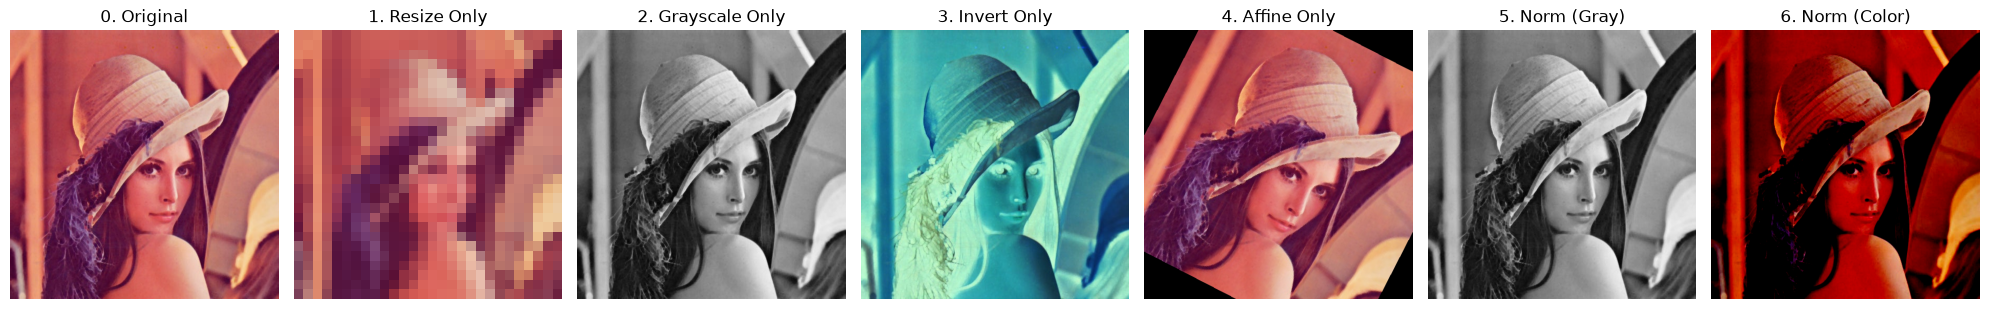


📊 [데이터 수치 변화 확인 (컬러 텐서 기준)]
[1] ToTensor()만 적용 (정규화 전):
 - 데이터 범위 : 0.0000 ~ 1.0000
 - 평균값(mean): 0.4636

[2] Normalize()까지 적용 (정규화 후):
 - 데이터 범위 : -1.0000 ~ 1.0000
 - 평균값(mean): -0.0728
💡 평균값이 0에 가까워지고, 범위가 음수와 양수(-1~1)로 넓어진 것을 확인하세요!



In [19]:
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

# 1. 로컬 이미지 로드
image_path = './images/lena.png' 
try:
    img = Image.open(image_path).convert('RGB')
except FileNotFoundError:
    print(f"'{image_path}' 파일을 찾을 수 없습니다. 경로를 확인해주세요.")
    exit()

# 2. 개별 변환 정의 (1대1 매칭용)
t_resize = transforms.Resize((28, 28))
t_gray = transforms.Grayscale(num_output_channels=1)
t_invert = transforms.RandomInvert(p=1.0)
t_affine = transforms.RandomAffine(degrees=50, translate=(0.08, 0.08), scale=(0.90, 1.10))

# 정규화를 위한 파이프라인
t_tensor = transforms.ToTensor() # 수치 비교용

t_norm_gray = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

t_norm_color = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

# 3. 원본(img)에 각각 1대1로 적용 (시각화용)
img_resize = t_resize(img)
img_gray = t_gray(img)
img_invert = t_invert(img)
img_affine = t_affine(img)

tensor_norm_gray = t_norm_gray(img)
tensor_norm_color = t_norm_color(img)

# 시각화를 위해 정규화된 텐서를 0~1 범위로 복원(역정규화) 후 배열로 변환
# img_norm_gray_vis = (tensor_norm_gray * 0.5 + 0.5).squeeze().numpy()
# img_norm_color_vis = (tensor_norm_color * 0.5 + 0.5).permute(1, 2, 0).numpy()
img_norm_gray_vis = tensor_norm_gray.squeeze().numpy()
img_norm_color_vis = tensor_norm_color.permute(1, 2, 0).numpy()

# 4. 시각화 출력 진행
imgs = [img, img_resize, img_gray, img_invert, img_affine, img_norm_gray_vis, img_norm_color_vis]
titles = [
    "0. Original", 
    "1. Resize Only", 
    "2. Grayscale Only", 
    "3. Invert Only", 
    "4. Affine Only",
    "5. Norm (Gray)",
    "6. Norm (Color)"
]

fig, axes = plt.subplots(1, len(imgs), figsize=(20, 3.5))
for i, (ax, image, title) in enumerate(zip(axes, imgs, titles)):
    # 흑백 이미지 처리
    if i in [2, 5]:
        ax.imshow(image, cmap='gray')
    else:
        ax.imshow(image)
    
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

# 5. 눈에 보이지 않는 '정규화' 수치 변화 출력
print("\n" + "="*50)
print("📊 [데이터 수치 변화 확인 (컬러 텐서 기준)]")
print("="*50)

# 정규화 전 순수 텐서 (0.0 ~ 1.0)
tensor_img = t_tensor(img) 

print("[1] ToTensor()만 적용 (정규화 전):")
print(f" - 데이터 범위 : {tensor_img.min().item():.4f} ~ {tensor_img.max().item():.4f}")
print(f" - 평균값(mean): {tensor_img.mean().item():.4f}")

print("\n[2] Normalize()까지 적용 (정규화 후):")
print(f" - 데이터 범위 : {tensor_norm_color.min().item():.4f} ~ {tensor_norm_color.max().item():.4f}")
print(f" - 평균값(mean): {tensor_norm_color.mean().item():.4f}")
print("="*50)
print("💡 평균값이 0에 가까워지고, 범위가 음수와 양수(-1~1)로 넓어진 것을 확인하세요!\n")

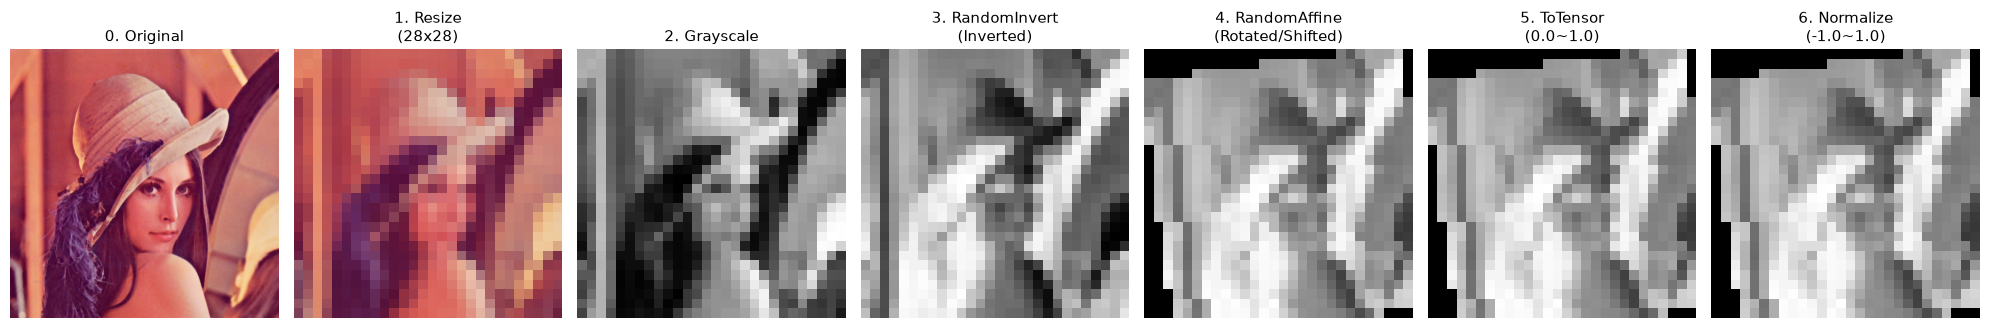

In [13]:
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

# 1. 로컬에 있는 Lena 이미지 로드
# 다운로드 받으신 파일 이름('image_ebdd45.jpg')과 경로에 맞게 지정해주세요.
image_path = './images/lena.png' 
img = Image.open(image_path).convert('RGB')

# 2. 각 변환 단계를 개별적으로 분리
t_resize = transforms.Resize((28, 28))
t_gray = transforms.Grayscale(num_output_channels=1)
t_invert = transforms.RandomInvert(p=1.0)
t_affine = transforms.RandomAffine(degrees=12, translate=(0.08, 0.08), scale=(0.90, 1.10))
t_tensor = transforms.ToTensor()
t_normalize = transforms.Normalize(mean=(0.5,), std=(0.5,))

# 3. 순차적으로 변환을 적용하며 리스트에 저장
imgs = [img]
titles = ["0. Original"]

imgs.append(t_resize(imgs[-1]))
titles.append("1. Resize\n(28x28)")

imgs.append(t_gray(imgs[-1]))
titles.append("2. Grayscale")

imgs.append(t_invert(imgs[-1]))
titles.append("3. RandomInvert\n(Inverted)")

imgs.append(t_affine(imgs[-1]))
titles.append("4. RandomAffine\n(Rotated/Shifted)")

# 5. ToTensor (시각화를 위해 PyTorch Tensor를 NumPy 배열로 변환)
img_tensor = t_tensor(imgs[-1])
imgs.append(img_tensor.squeeze().numpy()) 
titles.append("5. ToTensor\n(0.0~1.0)")

# 6. Normalize (시각화를 위해 역정규화 진행)
img_norm = t_normalize(img_tensor)
img_denorm = img_norm * 0.5 + 0.5 
imgs.append(img_denorm.squeeze().numpy())
titles.append("6. Normalize\n(-1.0~1.0)")

# 4. 전체 과정 나란히 시각화
fig, axes = plt.subplots(1, len(imgs), figsize=(20, 3.5))
for i, (ax, image, title) in enumerate(zip(axes, imgs, titles)):
    # 원본(0번째) 이미지는 컬러이므로 cmap='gray'를 적용하지 않음
    if i == 0:
        ax.imshow(image)
    else:
        ax.imshow(image, cmap='gray')
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

# **여기까지**

# **4. 학습/검증/테스트 데이터 분리**
- 학습   데이터: 가중치를 실제로 업데이트
- 검증   데이터: 학습 중 모델 선택과 과적합 확인에 사용
- 테스트 데이터: 모든 학습과 모델 선택이 끝난 뒤, 최종 성능을 확인

In [14]:
base_dataset = datasets.ImageFolder(train_dir)
class_names = base_dataset.classes
num_classes = len(class_names)
num_classes

3

In [15]:
print(base_dataset.targets)  # 정답

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


In [16]:
train_indices = []
val_indices = []
rng = np.random.default_rng(SEED)

for class_idx in range(num_classes):
    indices = np.where(np.array(base_dataset.targets) == class_idx)[0]     # where: 조건을 줬을 때 참/거짓으로 어떠한 것을 해라 / True인 애들만 indices에 저장됨
    rng.shuffle(indices) # 이미지 섞어줌
    split = int(len(indices) * 0.8)  # 80%만 이미지를 split에 넣어줌
    train_indices.extend(indices[:split].tolist())  # split을 train에 넣음
    val_indices.extend(indices[split:].tolist()) # 나머지 20% 넣음

#                                rain 새로 가져옴 / 데이터를 꺼낼 때 transform 사용
train_full = datasets.ImageFolder(train_dir, transform = train_transform)
val_full = datasets.ImageFolder(train_dir, transform = eval_transform)
test_dataset = datasets.ImageFolder(test_dir, transform = eval_transform)

# 기존 데이터셋에서 원하는 데이터만 선택하여 새로운 데이터셋을 생성
train_dataset = Subset(train_full, train_indices)
val_dataset = Subset(val_full, val_indices)

print('학습: ', len(train_dataset))
print('검증: ', len(val_dataset))
print('테스트: ', len(test_dataset))

학습:  192
검증:  48
테스트:  60


In [39]:
BATCH_SIZE = 32

# pin_memory=True
# CPU의 일반적인 메모리를 Pageable Memory라고 하고, GPU 전송에 유리하도록 고정된 CPU 메모리를 Pinned Memory라고 함
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)  # num_workers cpu 코어 전부 사용하겠다.
val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle=False, num_workers=0,pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle=False, num_workers=0,pin_memory=True)

# **5. 이미지와 텐서 모양 확인**
- CNN 입력 텐서: [배치, 채널, 높이, 너비]
- 현재 데이터의 배치 shape: [32, 1, 28, 28]

In [21]:
images, labels = next(iter(train_loader))
print('이미지 배치: ', images.shape)
print('레이블 배치: ', labels.shape)

이미지 배치:  torch.Size([32, 1, 28, 28])
레이블 배치:  torch.Size([32])


In [ ]:
# 이미지 찍기용으로 정규화 돌려놓기
def denormalize(image):
    return image * 0.5 + 0.5

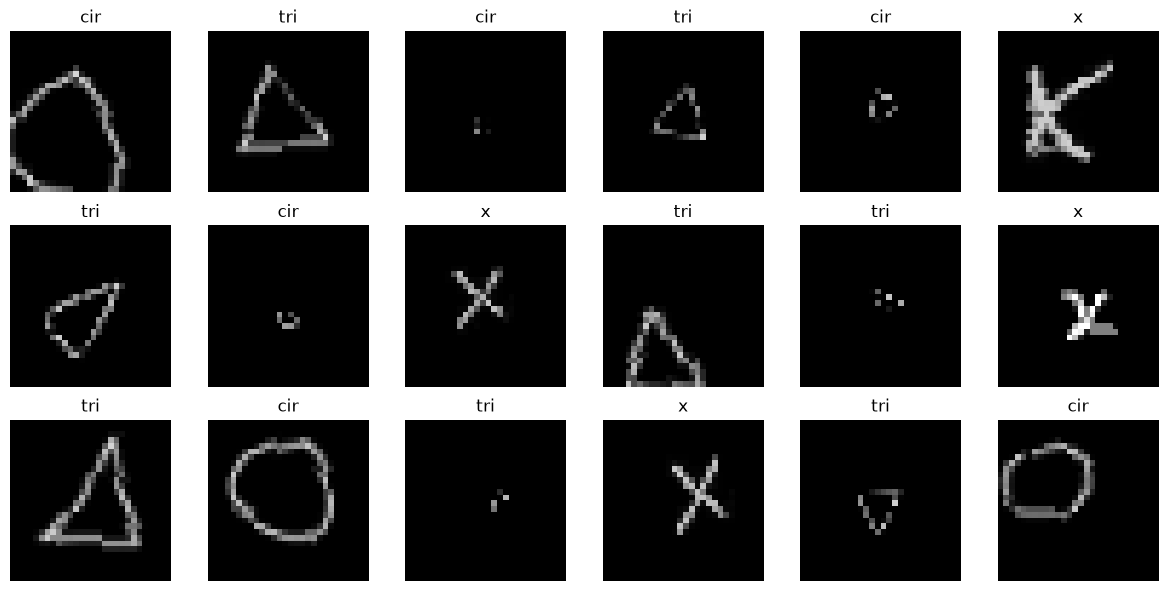

In [ ]:
fig, axes = plt.subplots(3, 6, figsize=(12, 6))
for ax, image, label in zip(axes.flat, images[:18], labels[:18]):
    ax.imshow(denormalize(image).squeeze(0), cmap='gray', vmin=0, vmax=1)   # 이미지를 반정규화 시켜서 흑백영상으로 만듦. 최소 값은 0이고 최대 값은 1이란 걸 알려줌
    ax.set_title(class_names[label.item()])
    ax.axis('off')  # 심심하면 주석처리해서 비교해보셈
plt.tight_layout()
plt.show()

# **6. CNN 모델**

### BatachNorm2d
CNN이 학습하면서 만들어낸 각 채널(feature map)의 값들을 적절한 범위로 정규화해서 학습을 더 안정적으로 만들어주는 층

```
입력 이미지 > Conv2d > 32rodml Feature Map 생성 > BatchNorm2d > 각 Feature Map의 값들을 정규화 > ReLU
nn.Conv2d(1, 32, kernel_size = 3, padding = 1, bias = False),
nn.BatchNorm2d(32), # 채널수
nn.ReLU()
```

> CNN의 Conv2d를 통과하면 값들이 여러가지로 변함. 처음 입력 이미지가 어느 정도 정규화되어 있어도 Conv2d를 통과하고 나면 가중치와 계산되면서 채널마다 값의 분포가 달라질 수 있음.
<br>BatchNorm은 값을 어느 정도 정돈해서 다음 층으로 보내주는 역할을 함

### AdaptiveAvgPool2d
- 입력 이미지의 크기가 얼마이든 상관없이 최종 출력 크기를 항상 특정 크기로 만들어주는 평균 풀링 레이어
- CNN에서 분류 모델의 마지막 부분에 자주 사용 / 여러 번 강조하심 Fully Connected Layer FClayer:완전연결층


```
nn.AdaptiveAvgPool2d(kernel_size=2)


숫자 맘대로 적은거임 참고
1 3 2 4
5 7 6 8
2 4 1 3
6 8 5 7

2*2의 평균을 계산 > (1+3+5+7)/=4

nn.AdaptiveAvgPool2d(1, 1)
입력 크기가 어떻게 생겼든 최종적으로 1 * 1로 만들어줘라

1 2
3 4

(1+2+3+4)/4 = 2.5
Feature Map 하나를 대표하는 값 하나가 만들어짐
```
```
예) Conv2d를 통과해서 Feature Map이 64개일 경우
[32, 64, 14, 14]  배치사이즈, 특징맵, 높이, 너비        너비아니
nn.AdaptiveAvgPool2d((1,1))
[32, 64, 1, 1]
```
> 채널 개수는 그대로 유지되고 H, W만 줄어듦

### Dropout
- 신경망이 학습할 때 일부 뉴런(노드)을 일부러 랜덤하게 꺼버리는 기법  (이게 딱 정의다/노드는 내가 쓴거임)
- 과적합 줄이기 위해 사용
- 네트워크에서 뉴런을 영국적으로 삭제하는 것이 아니며, 학습 순간에만 뉴런의 출력을 0으로 함
- model.train()시 Dropout 작동, model.eval() Dropout 꺼짐

In [ ]:
class ShapeCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(  # 우리 시퀀셜 배웠나?
            # 동일한 연산이 2개 있는 이유 성능이 더 좋대
            nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False),   # 이건 맘대로 만들면 됨 / 나중에 공부할 때 아무거나 넣어봐
            nn.BatchNorm2d(32), # 32인 이유는 위 32라   / 가중치가 있다 정도만 알아둬라
            nn.ReLU(inplace=True),      # False가 기본 값임. True는 값을 새로운 메모리로 만들지 않고 덮어쓰기. 메모리 절약
            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),  # 32로 받아서 32로 내보냄 / padding=1이 same이랑 같은 역할한대
            nn.BatchNorm2d(32),
            # BatchNorm에사 넘어온 Tensor를 별도의 새로운 Tensor로 복사해서 처리하지 말고, Tensor의 메모리를 직접 수정하여 메모리를 절약
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),  # 이미지 크기 반으로 됨

            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),   
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False), 
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2), 
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1,)), # 데이터를 1차원으로 만들어줌
            nn.Flatten(),
            nn.Dropout(p=0.25), # 드롭아웃 알잖아?? 25%는 끄고 훈련함
            nn.Linear(64, num_classes) # num_classes 위에 3이랑 정의함. 왜냐  x, cir, tri 이렇게 3개잖아
        )

def forward(self, x):
    x = self.features(x)
    return self.classifier(x)

In [29]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(DEVICE)

cpu


In [30]:
model = ShapeCNN(num_classes=num_classes).to(DEVICE)
model

ShapeCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2

In [31]:
criterion = nn.CrossEntropyLoss()

### AdamW
나왔다 Weight Decay
<br>그냥 weight decay 적용한 Adam임
- Adam에 가중치 감쇠(Weight Decay)를 적용하는 방식
- 딥러닝 모델의 가중치가 지나치게 커지면 학습 데이터에 너무 맞춰지는 과적합이 발생할 수 있음 > Weight Decay로 학습 중에 가중치를 조금씩 줄여서 너무 커지지 않도록 하는 방법을 사용
- 과적합을 줄이고 일반화 성능을 높이도록 만듦

```
Gradient > Adam의 적응적 계산 > 가중치 업데이트 > Weight Decay 적용

이건 내가 적은거임(살짝 얘기하심) -> Weight Decay 적용할 때 L2 규제 효과 줌
```

In [32]:
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay = 1e-4)

### Scheduler
- 검증 성능이 더 이상 좋아지지 않을 때 자동으로 학습률을 낮춰주는 기능
- 가중치 = 가중치 - 학습률 * 기울기

```
에폭은 설명만 하셨음
Epoch 또 너무 어렵게 설명하심. 그냥 훈련 횟수임 1이면 훈련 1번 50이면 훈련 50번

Epoch1 Loss: 0.8
Epoch2 Loss: 0.6
Epoch3 Loss: 0.5
Epoch4 Loss: 0.43
Epoch5 Loss: 0.40  # 이후로 Loss가 좋아지지 않음
Epoch6 Loss: 0.41
Epoch7 Loss: 0.42
Epoch8 Loss: 0.41
```

- mode: 무엇을 기준으로 좋아졌다고 판단할지를 결정
- factor: 학습률 반영값
- patience: 몇 번까지 참아줄 것인지 설정

In [ ]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience = 3 # max으로 하면 loss가 높을수록 좋다고 판단함 당연히 낮아야 좋아지니깐 min으로 
                                                    # patience가 3면 3번은 지켜보고 판단함
                                                    # factor는 3번을 참았는데 개선이 없으면 학습률(learning rate)에 * 0.5 해서
                                                    # 학습률 반토막냄
)


### 학습과 평가 함수

In [44]:
def run_epoch(model, loader, criterion, device, optimizer=None):
    is_training = optimizer is not None # optimizer 를 전달하면 True로 바뀜
    model.train() if is_training else model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    # enable_grad: 기울기 계산을 활성화
    # grad는 계산 결과를 계속 누적 시킴
    # inference_mode(): 메모리 사용량 감소. 불필요한 기울기 계산 방지
    context = torch.enable_grad() if is_training else torch.inference_mode()
    with context:
        for images, labels in loader:
            images = images.to(device, non_blocking = True)  # gpu 쓰고 있음 gpu로 보내서 속도 향상
            labels = label.to(device, non_blocking = True)  # non_blocking 쓰면 바로바로 보내짐 근데  non_blocking만 쓰면 안됨 위에 BATCH_SIZE = 32이 있는 곳 올라가봐
                                                            # 위에서 pinned_memory 없으면 non_blocking = True해도 의미 없음. 걍 세트임
            
            if is_training:
                # set_to_none: 기울기 값을 -으로 채우는 대신 None으로 설정
                # 메모리 사용을 줄일 수 있음. 불필요한 0 텐서 생성을 줄임
                optimizer.zero_grad(set_to_none=True)
            model = model.to(device)
            logits = model(images)
            loss = criterion(logits, labels)

            if is_training:
                loss.backward()
                optimizer.step()
            batch_size = labels.size(0)   # 2차원 배열로 되어있고 0을 넣으면 크기알 수 있음
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples




이제 아이디어 경쟁이 아니라 학습 속도 경쟁이래 

```
현재시간 12:26
이제 힘들다
졸려 죽겠음
```

### 모델 학습과 Early Stopping(조기종료)

이것도 저번에 애기했던 조기 종료
- 검증 손실이 가장 낮을 때의 가중치를 저장
- 일정 횟수 동안 검증 손실이 개선 되지 않으면 학습을 조기에 종료하여 과적합과 불필요한 학습을 줄임 

In [45]:
EPOCHS = 50
EARLY_STOPPING_PATIENCE = 8
best_val_loss = float('inf') # inf 무한대 무한 보단 무조건 작으니까 그래서 inf  무야호
wait = 0
history = {"train_loss":[], 'val_loss':[], 'train_acc': [], 'val_acc': []}
best_model_path = 'best_shape_cnn.pth'  # best_shape_cnn.h5     h5는 텐서플로 파이토치 다 사용 가능

In [46]:
# for epoch in range(1, EPOCHS+1):
#     train_loss, train_css = run_epoch(model, train_loader, criterion, DEVICE, optimizer)
#     val_loss, val_acc = run_epoch(model, val_loader, criterion, DEVICE)

# 혹시몰라서 주석처리함 실행하지 말래

### 수업 여기까지함 나머지는 월욜에 cpu 로 돌리면 1시간 넘게 돌릴거래

# ***경*** **조주영 졸업축하** ***축***